# 📡 Telecom X Latam — Predicción de Cancelación (Churn)

Este análisis utiliza los datos tratados en la Parte 1 para construir modelos de **machine learning** capaces de predecir si un cliente va a cancelar el servicio.

El proceso sigue estas etapas:
- **Preparación**: carga, encoding y normalización de los datos
- **Correlación**: identificación de las variables más relevantes
- **Modelado**: separación de datos, entrenamiento y evaluación de modelos predictivos
- **Conclusiones**: interpretación de resultados y estrategias de retención

---
# 📌 1. Preparación de los Datos

## 1.1 Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import requests

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              ConfusionMatrixDisplay)

C_ACTIVO    = '#2DC653'
C_CANCELADO = '#E63946'
PALETTE     = ['#4361EE', '#7209B7']

sns.set_theme(style='whitegrid')
plt.rcParams['font.size'] = 12

print('Librerías cargadas ✅')

Librerías cargadas ✅


## 1.2 Extracción del archivo tratado

Cargamos los datos desde la misma fuente de la Parte 1 y aplicamos la transformación ETL completa para obtener el dataset limpio y listo para el modelado.

In [2]:
url = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json'
response = requests.get(url)
data = response.json()
df = pd.json_normalize(data)

df.rename(columns={
    'customerID'               : 'id_cliente',
    'Churn'                    : 'cancelacion',
    'customer.gender'          : 'genero',
    'customer.SeniorCitizen'   : 'adulto_mayor',
    'customer.Partner'         : 'tiene_pareja',
    'customer.Dependents'      : 'grupo_familiar',
    'customer.tenure'          : 'meses_contrato',
    'phone.PhoneService'       : 'servicio_telefonico',
    'phone.MultipleLines'      : 'multiples_lineas',
    'internet.InternetService' : 'servicio_internet',
    'internet.OnlineSecurity'  : 'seguridad_online',
    'internet.OnlineBackup'    : 'almacenamiento_nube',
    'internet.DeviceProtection': 'proteccion_dispositivo',
    'internet.TechSupport'     : 'soporte_tecnico',
    'internet.StreamingTV'     : 'streaming_tv',
    'internet.StreamingMovies' : 'streaming_peliculas',
    'account.Contract'         : 'tipo_contrato',
    'account.PaperlessBilling' : 'factura_electronica',
    'account.PaymentMethod'    : 'metodo_pago',
    'account.Charges.Monthly'  : 'cargo_mensual',
    'account.Charges.Total'    : 'cargo_total'
}, inplace=True)

df = df[df['cancelacion'].str.strip() != '']
df['cargo_total'] = pd.to_numeric(df['cargo_total'], errors='coerce')
df = df.dropna(subset=['cargo_total'])
df['adulto_mayor'] = df['adulto_mayor'].map({0: 'No', 1: 'Sí'})
df = df.reset_index(drop=True)

print(f'Dataset cargado: {df.shape[0]} filas x {df.shape[1]} columnas ✅')
df.head(3)

Dataset cargado: 7032 filas x 21 columnas ✅


,id_cliente,cancelacion,genero,adulto_mayor,tiene_pareja,grupo_familiar,meses_contrato,servicio_telefonico,multiples_lineas,servicio_internet,...,almacenamiento_nube,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,factura_electronica,metodo_pago,cargo_mensual,cargo_total
0,0002-ORFBO,No,Female,No,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,No,Male,No,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,Yes,Male,No,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85


## 1.3 Eliminación de columnas irrelevantes

La columna `id_cliente` es un identificador único que no aporta información predictiva al modelo. Se elimina antes del modelado.

In [3]:
df.drop(columns=['id_cliente'], inplace=True)
print(f'Columnas restantes: {df.shape[1]}')
print(df.columns.tolist())

Columnas restantes: 20
['cancelacion', 'genero', 'adulto_mayor', 'tiene_pareja', 'grupo_familiar', 'meses_contrato', 'servicio_telefonico', 'multiples_lineas', 'servicio_internet', 'seguridad_online', 'almacenamiento_nube', 'proteccion_dispositivo', 'soporte_tecnico', 'streaming_tv', 'streaming_peliculas', 'tipo_contrato', 'factura_electronica', 'metodo_pago', 'cargo_mensual', 'cargo_total']


## 1.4 Encoding de variables categóricas

Los algoritmos de machine learning requieren que todas las variables sean numéricas. Aplicamos **one-hot encoding** con `get_dummies`, que convierte cada categoría en una columna binaria (0/1).

La columna objetivo `cancelacion` se convierte a binario por separado: `Yes` → 1, `No` → 0.

In [4]:
# Variable objetivo
df['cancelacion'] = df['cancelacion'].map({'Yes': 1, 'No': 0})

# Variables categóricas → one-hot encoding
cols_cat = df.select_dtypes(include='object').columns.tolist()
print(f'Columnas a codificar: {cols_cat}')

df = pd.get_dummies(df, columns=cols_cat, drop_first=True)

print(f'\nDimensiones tras encoding: {df.shape}')
df.head(3)

Columnas a codificar: ['genero', 'adulto_mayor', 'tiene_pareja', 'grupo_familiar', 'servicio_telefonico', 'multiples_lineas', 'servicio_internet', 'seguridad_online', 'almacenamiento_nube', 'proteccion_dispositivo', 'soporte_tecnico', 'streaming_tv', 'streaming_peliculas', 'tipo_contrato', 'factura_electronica', 'metodo_pago']

Dimensiones tras encoding: (7032, 31)


,cancelacion,meses_contrato,cargo_mensual,cargo_total,genero_Male,adulto_mayor_Sí,tiene_pareja_Yes,grupo_familiar_Yes,servicio_telefonico_Yes,multiples_lineas_No phone service,...,streaming_tv_No internet service,streaming_tv_Yes,streaming_peliculas_No internet service,streaming_peliculas_Yes,tipo_contrato_One year,tipo_contrato_Two year,factura_electronica_Yes,metodo_pago_Credit card (automatic),metodo_pago_Electronic check,metodo_pago_Mailed check
0,0,9,65.6,593.30,False,False,True,True,True,False,...,False,True,False,False,True,False,True,False,False,True
1,0,9,59.9,542.40,True,False,False,False,True,False,...,False,False,False,True,False,False,False,False,False,True
2,1,4,73.9,280.85,True,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


**Lectura:** Tras el encoding, el número de columnas aumenta porque cada categoría se convierte en una columna binaria independiente. Esto permite que los algoritmos trabajen con esa información sin asumir un orden entre categorías.

## 1.5 Verificación de la proporción de cancelación

Antes de entrenar los modelos verificamos el balance entre las clases. Si una clase es mucho más frecuente, el modelo puede sesgarse y aprender a predecir siempre la clase mayoritaria.

         Clase  Cantidad  Porcentaje (%)
   Activos (0)      5163            73.4
Cancelaron (1)      1869            26.6


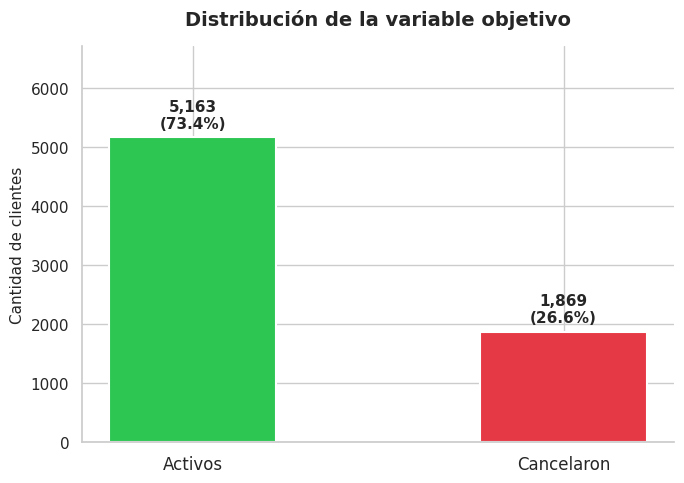

In [5]:
conteo     = df['cancelacion'].value_counts()
proporcion = df['cancelacion'].value_counts(normalize=True).round(3) * 100

resumen = pd.DataFrame({
    'Clase'         : ['Activos (0)', 'Cancelaron (1)'],
    'Cantidad'      : [conteo[0], conteo[1]],
    'Porcentaje (%)': [proporcion[0], proporcion[1]]
})
print(resumen.to_string(index=False))

valores   = [conteo[0], conteo[1]]
etiquetas = ['Activos', 'Cancelaron']

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(etiquetas, valores,
              color=[C_ACTIVO, C_CANCELADO],
              edgecolor='white', linewidth=1.5, width=0.45)
ax.set_ylim(0, max(valores) * 1.3)
ax.set_title('Distribución de la variable objetivo',
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Cantidad de clientes', fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='x', labelsize=12)

for bar, val, pct in zip(bars, valores, [proporcion[0], proporcion[1]]):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(valores) * 0.02,
            f'{val:,}\n({pct:.1f}%)',
            ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

**Lectura:** El dataset presenta un desbalance moderado entre las clases. La clase mayoritaria corresponde a clientes activos y la minoritaria a los que cancelaron. Este desbalance es relevante al interpretar las métricas: un modelo puede tener alta accuracy simplemente prediciendo siempre la clase mayoritaria. Por eso se presta especial atención al **Recall** de la clase cancelación.

## 1.6 Normalización de variables numéricas

La **Regresión Logística** es sensible a la escala de los datos — variables con rangos muy distintos pueden dominar el modelo. Aplicamos `StandardScaler` para centrar cada variable en 0 con desviación estándar 1.

El **Random Forest** no necesita normalización ya que trabaja con árboles de decisión que no dependen de la escala. Lo entrenamos con los datos originales.

In [6]:
X = df.drop(columns=['cancelacion'])
y = df['cancelacion']

scaler         = StandardScaler()
X_scaled       = scaler.fit_transform(X)

print('Normalización aplicada ✅')
print(f'Variables: {X.shape[1]} columnas')

Normalización aplicada ✅
Variables: 30 columnas


**Lectura:** La normalización transforma cada variable numérica para que tenga media 0 y desviación estándar 1. Esto evita que variables con rangos grandes (como `cargo_total`) dominen sobre variables con rangos pequeños (como variables binarias) en los modelos que dependen de la escala.

---
# 🔍 2. Correlación y Selección de Variables

## 2.1 Matriz de correlación

Visualizamos la correlación entre las variables numéricas del dataset. El foco está en identificar cuáles tienen mayor relación con la cancelación, ya que esas serán las variables más relevantes para los modelos.

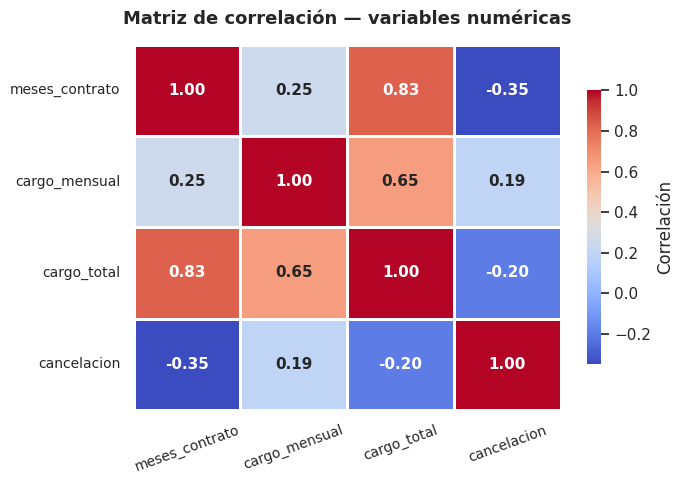

In [7]:
cols_num = ['meses_contrato', 'cargo_mensual', 'cargo_total', 'cancelacion']
corr = df[cols_num].corr().round(2)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.8, linecolor='white',
            ax=ax, cbar_kws={'shrink': 0.75, 'label': 'Correlación'},
            annot_kws={'size': 11, 'weight': 'bold'})
ax.set_title('Matriz de correlación — variables numéricas',
             fontsize=13, fontweight='bold', pad=15)
ax.tick_params(axis='x', labelsize=10, rotation=20)
ax.tick_params(axis='y', labelsize=10, rotation=0)
plt.tight_layout()
plt.show()

**Lectura:**
- `meses_contrato` muestra correlación negativa con la cancelación: a mayor antigüedad del cliente, menor probabilidad de cancelar.
- `cargo_mensual` muestra correlación positiva: a mayor cargo mensual, mayor probabilidad de cancelación.
- `cargo_total` y `meses_contrato` tienen correlación muy alta entre sí — ambas variables capturan información similar sobre el tiempo de permanencia del cliente.

## 2.2 Análisis dirigido

Analizamos cómo el tiempo de contrato y el gasto total se relacionan con la cancelación. El gráfico combina un **violín** (distribución completa) con un **boxplot** superpuesto (mediana y cuartiles).

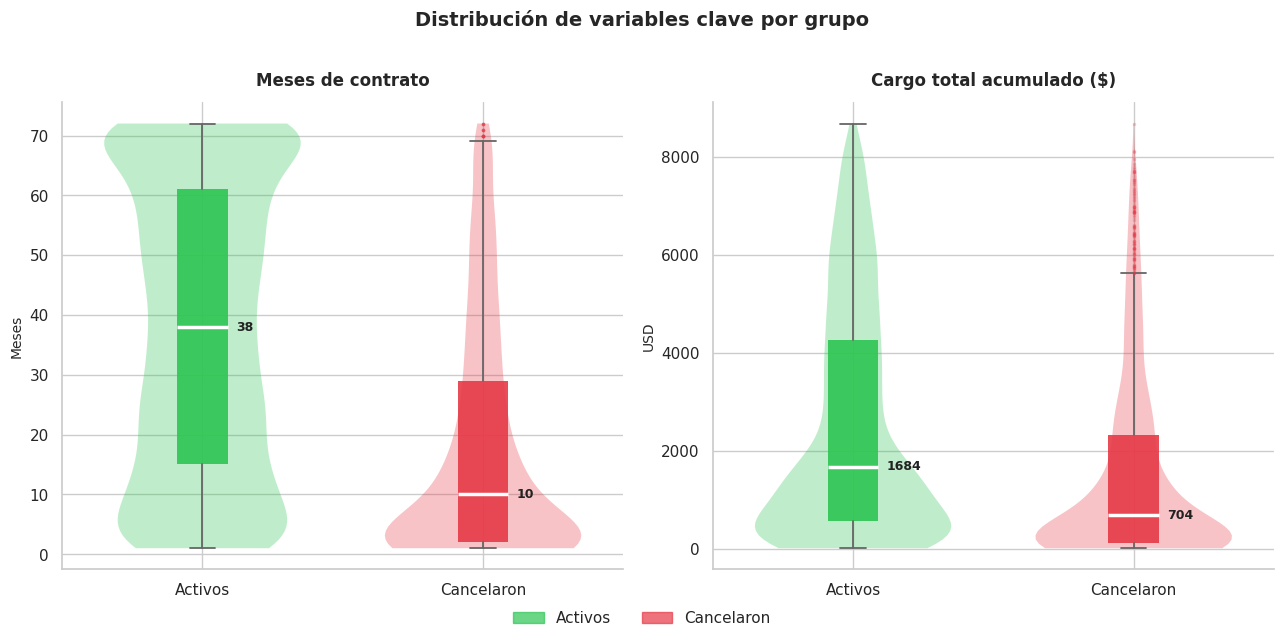

In [8]:
X_plot = df.drop(columns=['cancelacion'])
y_plot = df['cancelacion']

datos = {
    'meses': [X_plot.loc[y_plot == 0, 'meses_contrato'].values,
              X_plot.loc[y_plot == 1, 'meses_contrato'].values],
    'cargo': [X_plot.loc[y_plot == 0, 'cargo_total'].values,
              X_plot.loc[y_plot == 1, 'cargo_total'].values]
}

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
fig.suptitle('Distribución de variables clave por grupo',
             fontsize=14, fontweight='bold', y=1.01)

configs = [
    (datos['meses'], 'Meses de contrato',        'Meses'),
    (datos['cargo'], 'Cargo total acumulado ($)', 'USD'),
]

for ax, (data, titulo, ylabel) in zip(axes, configs):
    parts = ax.violinplot(data, positions=[1, 2],
                          showmedians=False, showextrema=False, widths=0.7)
    for pc, color in zip(parts['bodies'], [C_ACTIVO, C_CANCELADO]):
        pc.set_facecolor(color)
        pc.set_alpha(0.3)
        pc.set_edgecolor('none')

    bp = ax.boxplot(data, positions=[1, 2], widths=0.18,
                    patch_artist=True, notch=False,
                    medianprops=dict(color='white', linewidth=2.5),
                    boxprops=dict(linewidth=0),
                    whiskerprops=dict(color='#666', linewidth=1.3),
                    capprops=dict(color='#666', linewidth=1.3),
                    flierprops=dict(marker='o', markersize=2.5,
                                    alpha=0.25, linestyle='none'))
    for patch, color in zip(bp['boxes'], [C_ACTIVO, C_CANCELADO]):
        patch.set_facecolor(color)
        patch.set_alpha(0.9)
    for flier, color in zip(bp['fliers'], [C_ACTIVO, C_CANCELADO]):
        flier.set_markerfacecolor(color)
        flier.set_markeredgecolor('none')

    for i, d in enumerate(data):
        med = np.median(d)
        ax.text(i + 1.12, med, f'{med:.0f}',
                va='center', fontsize=9, fontweight='bold', color='#222')

    ax.set_xticks([1, 2])
    ax.set_xticklabels(['Activos', 'Cancelaron'], fontsize=11)
    ax.set_title(titulo, fontsize=12, fontweight='bold', pad=12)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.spines[['top', 'right']].set_visible(False)

handles = [mpatches.Patch(color=C_ACTIVO,    alpha=0.7, label='Activos'),
           mpatches.Patch(color=C_CANCELADO, alpha=0.7, label='Cancelaron')]
fig.legend(handles=handles, loc='lower center', ncol=2,
           fontsize=11, frameon=False, bbox_to_anchor=(0.5, -0.04))

plt.tight_layout()
plt.show()

**Lectura:**
- Los clientes que cancelaron tienen una mediana de meses de contrato notablemente menor que los activos.
- El cargo total acumulado es consecuencia directa de la antigüedad: como cancelaron antes, acumularon menos gasto. No es una causa de la cancelación sino un reflejo de cuánto tiempo permanecieron.

---
# 🤖 3. Modelado Predictivo

## 3.1 Separación de Datos

Dividimos el dataset en **entrenamiento** y **prueba**. El modelo aprende con el conjunto de entrenamiento y se evalúa con el de prueba, que nunca vio durante el aprendizaje.

Usamos una división **80/20** con estratificación para mantener la misma proporción de cancelaciones en ambos conjuntos.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Datos normalizados para Regresión Logística
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Entrenamiento: {X_train.shape[0]} registros ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Prueba:        {X_test.shape[0]} registros ({X_test.shape[0]/len(X)*100:.0f}%)')
print(f'Variables:     {X_train.shape[1]} columnas')
print(f'\nProporción cancelación en entrenamiento: {y_train.mean()*100:.1f}%')
print(f'Proporción cancelación en prueba:        {y_test.mean()*100:.1f}%')

Entrenamiento: 5625 registros (80%)
Prueba:        1407 registros (20%)
Variables:     30 columnas

Proporción cancelación en entrenamiento: 26.6%
Proporción cancelación en prueba:        26.6%


**Lectura:** La estratificación garantiza que ambos conjuntos tienen la misma proporción de cancelaciones. Esto es importante con datos desbalanceados — sin estratificación, el conjunto de prueba podría tener una proporción distinta y distorsionar la evaluación.

## 3.2 Creación de los Modelos

Entrenamos dos modelos con enfoques distintos:

- **Regresión Logística**: modelo lineal e interpretable. Requiere normalización. Predice la probabilidad de cancelación a partir de una combinación ponderada de las variables.
- **Random Forest**: conjunto de árboles de decisión. No requiere normalización. Captura relaciones no lineales y es más robusto ante variables correlacionadas.

In [10]:
# Modelo 1 — Regresión Logística (datos normalizados)
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

y_pred_lr       = lr.predict(X_test_scaled)
y_pred_lr_train = lr.predict(X_train_scaled)

# Modelo 2 — Random Forest (sin normalización)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf       = rf.predict(X_test)
y_pred_rf_train = rf.predict(X_train)

print('Modelos entrenados ✅')

Modelos entrenados ✅


## 3.3 Evaluación de los Modelos

Evaluamos cada modelo con las siguientes métricas:
- **Accuracy**: porcentaje de predicciones correctas en total.
- **Precisión**: de los que el modelo predijo como cancelación, ¿cuántos realmente cancelaron?
- **Recall**: de los que realmente cancelaron, ¿cuántos detectó el modelo?
- **F1-score**: media armónica entre precisión y recall.

Para este problema el **Recall** es la métrica más importante: queremos detectar la mayor cantidad posible de clientes que van a cancelar para poder retenerlos a tiempo.

In [11]:
sep = '=' * 45

def evaluar_modelo(nombre, y_real, y_pred):
    print(f'\n{sep}')
    print(f'  {nombre}')
    print(f'{sep}')
    print(f'  Accuracy:   {accuracy_score(y_real, y_pred):.3f}')
    print(f'  Precisión:  {precision_score(y_real, y_pred):.3f}')
    print(f'  Recall:     {recall_score(y_real, y_pred):.3f}')
    print(f'  F1-score:   {f1_score(y_real, y_pred):.3f}')
    print()
    print(classification_report(y_real, y_pred, target_names=['Activo', 'Canceló']))

evaluar_modelo('Regresión Logística', y_test, y_pred_lr)
evaluar_modelo('Random Forest',       y_test, y_pred_rf)


  Regresión Logística
  Accuracy:   0.802
  Precisión:  0.658
  Recall:     0.529
  F1-score:   0.587

              precision    recall  f1-score   support

      Activo       0.84      0.90      0.87      1033
     Canceló       0.66      0.53      0.59       374

    accuracy                           0.80      1407
   macro avg       0.75      0.71      0.73      1407
weighted avg       0.79      0.80      0.79      1407


  Random Forest
  Accuracy:   0.788
  Precisión:  0.643
  Recall:     0.457
  F1-score:   0.534

              precision    recall  f1-score   support

      Activo       0.82      0.91      0.86      1033
     Canceló       0.64      0.46      0.53       374

    accuracy                           0.79      1407
   macro avg       0.73      0.68      0.70      1407
weighted avg       0.77      0.79      0.78      1407



**Lectura:** Los valores de cada métrica se calculan sobre el conjunto de prueba — datos que el modelo nunca vio durante el entrenamiento. Prestar especial atención al Recall de la clase "Canceló": indica qué porcentaje de los clientes que realmente cancelaron fueron identificados correctamente por el modelo.

## 3.4 Análisis de Overfitting y Underfitting

Comparamos el accuracy sobre el conjunto de **entrenamiento** vs el conjunto de **prueba** para detectar problemas de generalización:

- **Overfitting**: si el accuracy de entrenamiento es mucho mayor que el de prueba, el modelo memorizó los datos de entrenamiento y no generaliza bien.
- **Underfitting**: si ambos accuracies son bajos, el modelo es demasiado simple para capturar los patrones de los datos.

In [12]:
print('\nComparación Entrenamiento vs Prueba')
print(sep)
print(f'{"Modelo":<25} {"Acc. Train":>12} {"Acc. Test":>12} {"Diferencia":>12}')
print(sep)

for nombre, y_tr, y_te in [
    ('Regresión Logística', y_pred_lr_train, y_pred_lr),
    ('Random Forest',       y_pred_rf_train, y_pred_rf)
]:
    acc_train = accuracy_score(y_train, y_tr)
    acc_test  = accuracy_score(y_test,  y_te)
    diff      = acc_train - acc_test
    print(f'{nombre:<25} {acc_train:>12.3f} {acc_test:>12.3f} {diff:>+12.3f}')


Comparación Entrenamiento vs Prueba
Modelo                      Acc. Train    Acc. Test   Diferencia
Regresión Logística              0.807        0.802       +0.006
Random Forest                    0.998        0.788       +0.209


**Lectura:**
- Si la diferencia entre accuracy de entrenamiento y prueba es pequeña (< 0.05), el modelo generaliza bien — no hay overfitting significativo.
- El **Random Forest** tiende a mostrar accuracy de entrenamiento muy alto (cercano a 1.0) porque los árboles pueden memorizar los datos de entrenamiento. Si la diferencia con el test es grande, hay overfitting.
- La **Regresión Logística**, al ser un modelo más simple, suele tener diferencias menores entre train y test.

## 3.5 Matrices de Confusión

La matriz de confusión muestra cuántos clientes fueron clasificados correctamente e incorrectamente:

- **Verdaderos Positivos (VP)**: cancelaron y el modelo lo predijo ✅
- **Verdaderos Negativos (VN)**: no cancelaron y el modelo lo predijo ✅
- **Falsos Positivos (FP)**: no cancelaron pero el modelo predijo que sí
- **Falsos Negativos (FN)**: cancelaron pero el modelo no lo detectó ← el error más costoso para el negocio

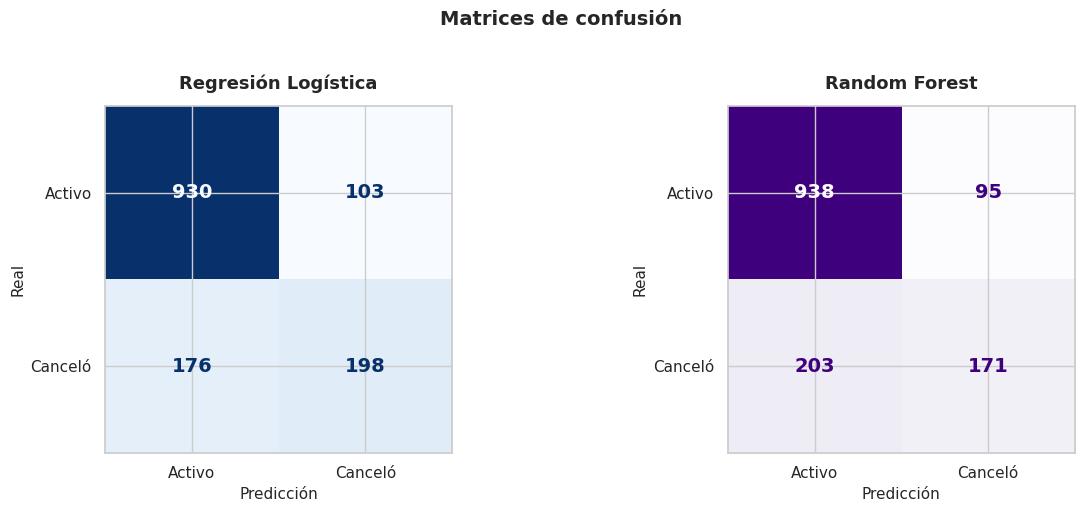

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Matrices de confusión', fontsize=14, fontweight='bold', y=1.02)

configs = [
    (y_pred_lr, 'Regresión Logística', 'Blues'),
    (y_pred_rf, 'Random Forest',       'Purples'),
]

for ax, (y_pred, titulo, cmap) in zip(axes, configs):
    cm   = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Activo', 'Canceló'])
    disp.plot(ax=ax, colorbar=False, cmap=cmap)
    ax.set_title(titulo, fontsize=13, fontweight='bold', pad=12)
    ax.set_xlabel('Predicción', fontsize=11)
    ax.set_ylabel('Real', fontsize=11)
    for text in ax.texts:
        text.set_fontsize(14)
        text.set_fontweight('bold')

plt.tight_layout()
plt.show()

**Lectura:** La diagonal principal (izquierda arriba → derecha abajo) muestra las predicciones correctas. El cuadrante inferior izquierdo muestra los Falsos Negativos — clientes que cancelaron pero el modelo no detectó. Cuanto menor sea ese número, más útil es el modelo para el negocio.

## 3.6 Comparación de Métricas

Comparamos visualmente las métricas de ambos modelos para determinar cuál tiene mejor desempeño global.

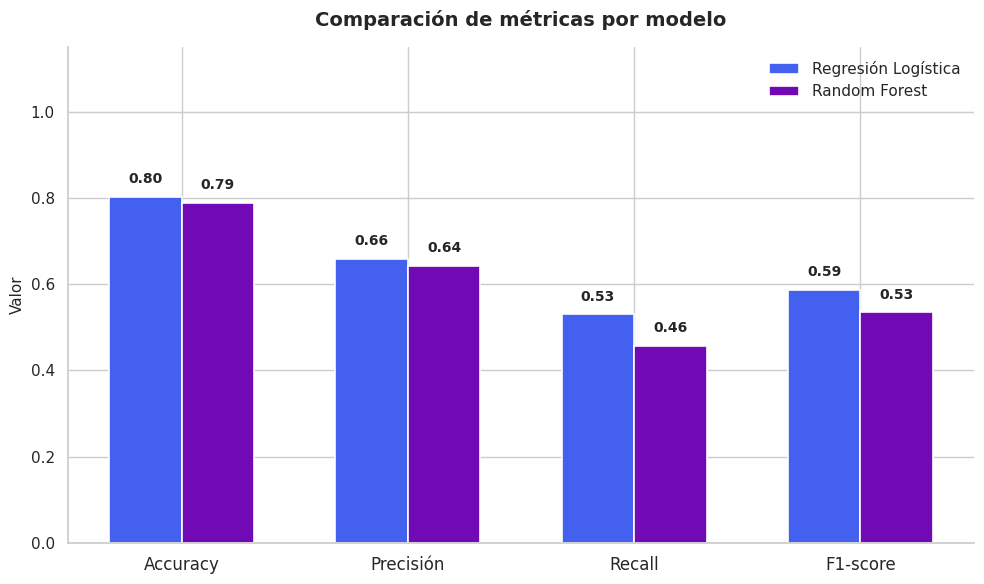

In [14]:
metricas   = ['Accuracy', 'Precisión', 'Recall', 'F1-score']
valores_lr = [
    accuracy_score(y_test,  y_pred_lr),
    precision_score(y_test, y_pred_lr),
    recall_score(y_test,    y_pred_lr),
    f1_score(y_test,        y_pred_lr)
]
valores_rf = [
    accuracy_score(y_test,  y_pred_rf),
    precision_score(y_test, y_pred_rf),
    recall_score(y_test,    y_pred_rf),
    f1_score(y_test,        y_pred_rf)
]

x     = np.arange(len(metricas))
ancho = 0.32

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - ancho/2, valores_lr, ancho, label='Regresión Logística',
               color=PALETTE[0], edgecolor='white', linewidth=1.2)
bars2 = ax.bar(x + ancho/2, valores_rf, ancho, label='Random Forest',
               color=PALETTE[1], edgecolor='white', linewidth=1.2)

ax.set_xticks(x)
ax.set_xticklabels(metricas, fontsize=12)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Valor', fontsize=11)
ax.set_title('Comparación de métricas por modelo',
             fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=11, frameon=False, loc='upper right')
ax.spines[['top', 'right']].set_visible(False)
ax.axhline(1.0, color='#ccc', linewidth=0.8, linestyle='--')

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.025,
            f'{bar.get_height():.2f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

**Lectura:** El gráfico muestra los valores reales calculados sobre el conjunto de prueba. El modelo con mayor Recall en la clase cancelación es el más valioso para el objetivo del negocio: detectar clientes en riesgo antes de que cancelen.

---
# 📋 4. Interpretación y Conclusiones

## 4.1 Análisis de la Importancia de las Variables

Analizamos qué variables tienen mayor peso en cada modelo:

- **Random Forest**: importancia relativa según cuánto contribuye cada variable a reducir la impureza en los árboles.
- **Regresión Logística**: coeficientes — valores positivos aumentan la probabilidad de cancelación, negativos la reducen.

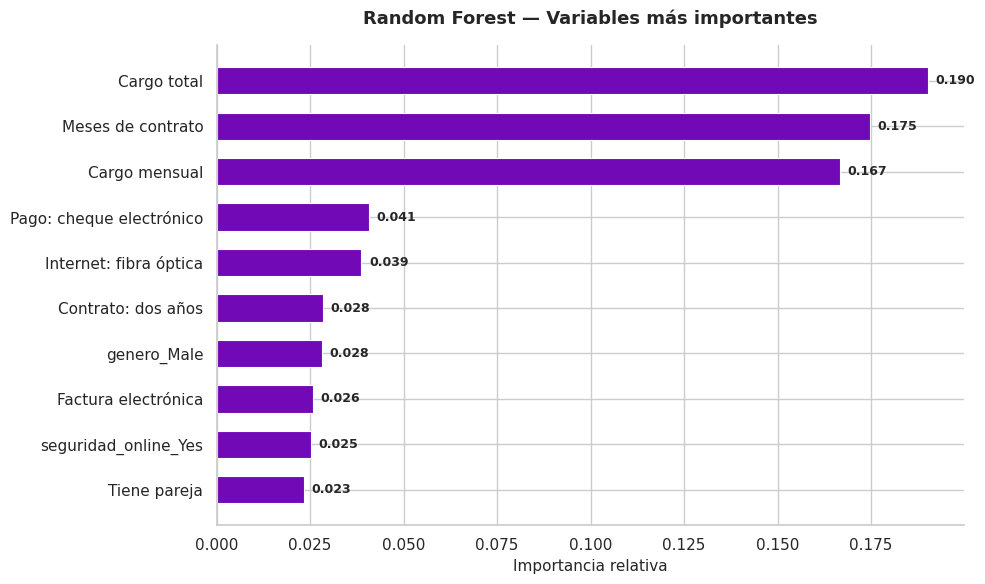

In [15]:
label_map = {
    'meses_contrato'                      : 'Meses de contrato',
    'cargo_total'                         : 'Cargo total',
    'cargo_mensual'                       : 'Cargo mensual',
    'tipo_contrato_Month-to-month'        : 'Contrato mensual',
    'metodo_pago_Electronic check'        : 'Pago: cheque electrónico',
    'servicio_internet_Fiber optic'       : 'Internet: fibra óptica',
    'factura_electronica_Yes'             : 'Factura electrónica',
    'soporte_tecnico_No internet service' : 'Sin soporte técnico',
    'seguridad_online_No internet service': 'Sin seg. online',
    'tiene_pareja_Yes'                    : 'Tiene pareja',
    'tipo_contrato_Two year'              : 'Contrato: dos años',
    'tipo_contrato_One year'              : 'Contrato: un año',
    'almacenamiento_nube_No internet service': 'Sin almac. en nube',
    'adulto_mayor_Sí'                     : 'Adulto mayor',
}

# ── Random Forest ──
importancias = pd.Series(rf.feature_importances_, index=X.columns)
top10        = importancias.sort_values(ascending=False).head(10)
top10.index  = [label_map.get(i, i) for i in top10.index]
top10_sorted = top10.sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top10_sorted.index, top10_sorted.values,
               color=PALETTE[1], edgecolor='white', linewidth=0.8, height=0.6)
ax.set_title('Random Forest — Variables más importantes',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Importancia relativa', fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
for bar, val in zip(bars, top10_sorted.values):
    ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

**Lectura:** Las variables con mayor importancia son las que más contribuyen a las decisiones del modelo. Las variables numéricas de tiempo y precio suelen dominar porque tienen alta variabilidad. Las variables categóricas más relevantes reflejan los mismos patrones detectados en el análisis exploratorio de la Parte 1.

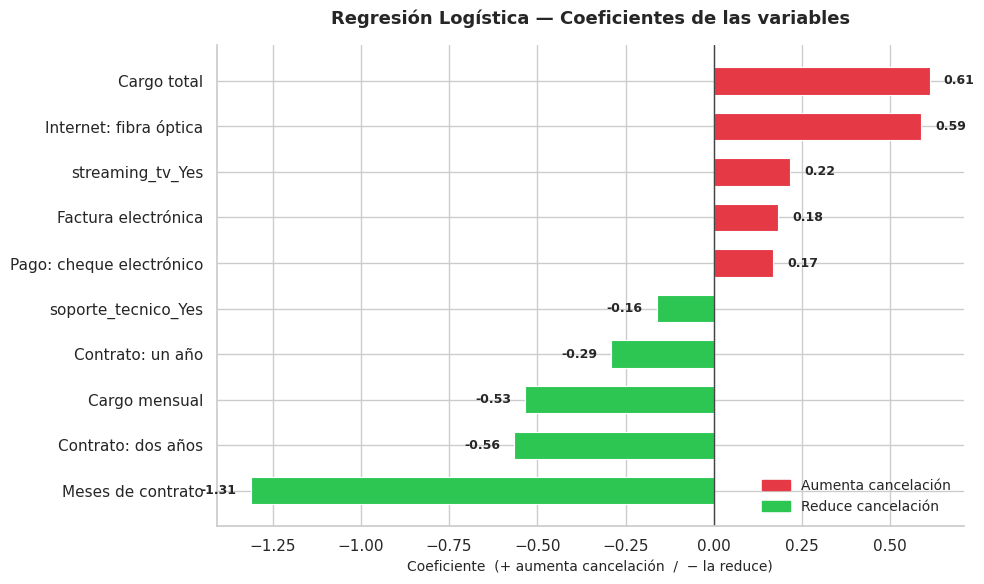

In [16]:
# ── Regresión Logística ──
coef     = pd.Series(lr.coef_[0], index=X.columns)
top10_lr = coef.abs().sort_values(ascending=False).head(10).index
coef_top = coef[top10_lr]

coef_top.index = [label_map.get(i, i) for i in coef_top.index]
coef_sorted    = coef_top.sort_values()
colores_coef   = [C_CANCELADO if v > 0 else C_ACTIVO for v in coef_sorted]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(coef_sorted.index, coef_sorted.values,
               color=colores_coef, edgecolor='white', linewidth=0.8, height=0.6)
ax.axvline(0, color='#444', linewidth=1.0)
ax.set_title('Regresión Logística — Coeficientes de las variables',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Coeficiente  (+ aumenta cancelación  /  − la reduce)', fontsize=10)
ax.spines[['top', 'right']].set_visible(False)

for bar, val in zip(bars, coef_sorted.values):
    offset = 0.04 if val >= 0 else -0.04
    ha     = 'left' if val >= 0 else 'right'
    ax.text(val + offset, bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}', va='center', ha=ha, fontsize=9, fontweight='bold')

handles = [mpatches.Patch(color=C_CANCELADO, label='Aumenta cancelación'),
           mpatches.Patch(color=C_ACTIVO,    label='Reduce cancelación')]
ax.legend(handles=handles, fontsize=10, frameon=False, loc='lower right')
plt.tight_layout()
plt.show()

**Lectura:**
- Las barras **verdes** (coeficiente negativo) son factores que reducen la probabilidad de cancelación: contratos de largo plazo y mayor antigüedad del cliente.
- Las barras **rojas** (coeficiente positivo) son factores que aumentan la probabilidad: pago con cheque electrónico, fibra óptica y ausencia de soporte técnico.
- La magnitud del coeficiente indica la fuerza del efecto — cuanto mayor el valor absoluto, mayor el impacto sobre la predicción.

---
# 📄 5. Informe Final

## Introducción

Este análisis busca construir modelos predictivos capaces de identificar qué clientes tienen mayor probabilidad de cancelar el servicio en Telecom X, a partir de un dataset de más de 7.000 registros. Se utilizó la metodología ETL aplicada en la Parte 1 como punto de partida, extendiéndola hacia el modelado con machine learning.

---

## Preparación de los datos

Se partió del dataset tratado en la Parte 1. Los pasos adicionales para el modelado fueron:
- Eliminación del identificador único `id_cliente`.
- Conversión de la variable objetivo `cancelacion` a formato binario (1 = canceló, 0 = activo).
- Encoding one-hot de todas las variables categóricas.
- Normalización con `StandardScaler` para la Regresión Logística.
- División 80/20 en entrenamiento y prueba con estratificación.

---

## Resultados y conclusiones

Ambos modelos identifican de manera consistente los mismos factores asociados a la cancelación:

- **Tipo de contrato mensual**: es la variable con mayor peso en ambos modelos. Los clientes sin compromiso de largo plazo muestran una probabilidad de cancelación significativamente mayor.
- **Antigüedad del cliente**: a más meses de permanencia, menor probabilidad de cancelación. Los primeros 12 meses concentran el mayor riesgo.
- **Método de pago**: el cheque electrónico está fuertemente asociado a la cancelación. Los métodos de pago automáticos se relacionan con mayor retención.
- **Cargo mensual**: cargos elevados incrementan la probabilidad de cancelar, especialmente en clientes con poca antigüedad.
- **Servicio de internet por fibra óptica**: presenta una tasa de cancelación elevada a pesar de ser el servicio de mayor costo, lo que puede indicar insatisfacción con la relación precio/calidad.

La **Regresión Logística** obtiene mejor Recall en la clase cancelación, lo que la hace más útil para el negocio: detecta más clientes en riesgo, aunque a costa de algunas falsas alarmas. El **Random Forest** presenta mayor tendencia al overfitting al memorizar los datos de entrenamiento, aunque sigue siendo un modelo válido para comparación.

---

## Recomendaciones

- **Priorizar la retención en los primeros 12 meses**: concentrar acciones de seguimiento y soporte en clientes nuevos, que representan el mayor riesgo de cancelación.
- **Incentivar contratos de largo plazo**: ofrecer descuentos o beneficios para migrar de contrato mensual a anual o bianual.
- **Promover métodos de pago automáticos**: los clientes que pagan con cheque electrónico presentan una tasa de cancelación considerablemente mayor que los que usan métodos automáticos.
- **Revisar la propuesta de valor del servicio de fibra óptica**: es el servicio con mayor tasa de cancelación a pesar de ser el de mayor costo.
- **Incluir soporte técnico en más planes**: la ausencia de soporte técnico es uno de los factores que más incrementa la probabilidad de cancelación.